# QSP
----

## QSP 数学原理

### 1. 从 Chebyshev 到 QSP
上一节已经得到 $x=\cos\theta$, 以及约定 signal unitary:
$$
W(x)=\begin{bmatrix}
x & i\sqrt{1-x^2} \\
i\sqrt{1-x^2} & x
\end{bmatrix}
$$
所以有
$$
W(x)=\begin{bmatrix}
\cos\theta & i\sin\theta \\
i\sin\theta & \cos\theta
\end{bmatrix}=e^{i\theta X}
$$
若什么都不做, 只执行 $W(x)^d$, 能得到
$$
[W(x)^d]_{00}=\cos(d\theta)=T_d(x)
$$
这就是上一节的 Qubitized Walk -> Chebyshev.

QSP 的想法就是
> 在这些 $W(x)$ 之间插入可调节的 phase, 使其成为任意多项式.

### 2. 加入 Phase Gate
定义
$$
S(\phi)=e^{i\phi Z}=\begin{bmatrix}
e^{i\phi} & 0 \\
0 & e^{-i\phi}
\end{bmatrix}
$$
然后构造
$$
U_\Phi(x)=S(\phi_0)W(x)S(\phi_1)W(x)\cdots W(x)S(\phi_d)
$$
这里的
$$
\Phi=(\phi_0,\phi_1,\cdots,\phi_d)
$$
若 $degree=d$, 就需要 $d+1$ 个 phase gate.

### 3. QSP 最重要的结果
最终 $U_\Phi(x)$ 可以写成类似
$$
U_\Phi(x) = \begin{bmatrix}
P(x) & i\sqrt{1-x^2} Q(x) \\
i\sqrt{1-x^2} Q^*(x) & P^*(x)
\end{bmatrix}
$$
因此有
$$
[U_\Phi(x)]_{00}=P(x)
$$

### 4. 若没有 phase 会发生什么
设
$$
\phi_0=\phi_1=\cdots=\phi_d=0
$$
则有 $S(0)=I$, 于是可以得到
$$
U_0(x)=W(x)^d
$$
因此
$$
P(x)=T_d(x)
$$
可以理解为 Chebyshev 是 QSP 的一个特殊情况

### 5. 一个二阶 QSP 的简单例子
考虑
$$
W(x)S(\phi)W(x)
$$
其左上角可以算出
$$
P(x)=2\cos\phi x^2-e^{-i\phi}
$$
所以 phase 的功能就是: 控制多项式的系数.

### 6. QSP 并不能实现任意的多项式
对于 $degree\ d$, 通常需要满足
$$
\deg P\leq d
$$
同时存在奇偶性约束:
$$
P(-x)=(-1)^d P(x)
$$
例如:
- $d$ 是偶数 -> $P(x)$ 是偶多项式
- $d$ 是奇数 -> $P(x)$ 是奇多项式

还要满足 unitary 导出的约束:
$$
|P(x)|^2+(1-x^2)|Q(x)|^2=1,\quad x\in[-1,1]
$$
因此不是任意的多项式都能实现.

### 7. QSP 多项式逼近
现在给定一个目标函数
$$
f(x),\quad x\in[-1,1]
$$
要寻找
$$
P_d(x)\approx f(x)
$$
然后再寻找 phase:
$$
\Phi \ s.t.\ U_\Phi(x)_{00}\approx P_d(x)
$$
因此整个流程是:
$$
f(x)\to P_d(x)\to \Phi\to QSP\ circuit
$$

### 8. 本节所选实验: 逼近 $\cos(tx)$
选择
$$
f(x)=\cos(tx),\quad t=1,\quad d=10
$$

[QSP]: Starting QSP Algorithm
[QSP]: Input parameters: 
        - Evolution time (t) = 1.0
        - Polynomial degree (d) = 10
        - Test eigenvalue (x) = 0.5
[QSP]: Stage 1: Target function analysis and phase sequence optimization
[QSP]:   Target evolution operator: cos(1.0000 * x)
[QSP]:   Optimization algorithm: L-BFGS-B (sampling points: 21)
[QSP]: Stage 2: Construct QSP quantum circuit building blocks
[QSP]:   Mount initial phase rotation: Rz(0.9716)
[QSP]:   Loop mount 10 groups [signal operator W(x) + phase rotation Rz]
[QSP]: Stage 3: Execute quantum simulation calculation
[QSP]:   Underlying simulation computation time: 0.004993 seconds
[QSP]: Stage 4: Accuracy comparison analysis and post-processing
[QSP]:   Test point x = 0.5
[QSP]:   Theoretical expected real part: 0.877583, simulated real part: 0.878829
[QSP]:   Absolute error (L2): 7.696138e-03
[QSP]: Stage 5: Export quantum circuit diagram
[QSP]: Output information: 
        - Estimated value = (0.8788294852399935+0

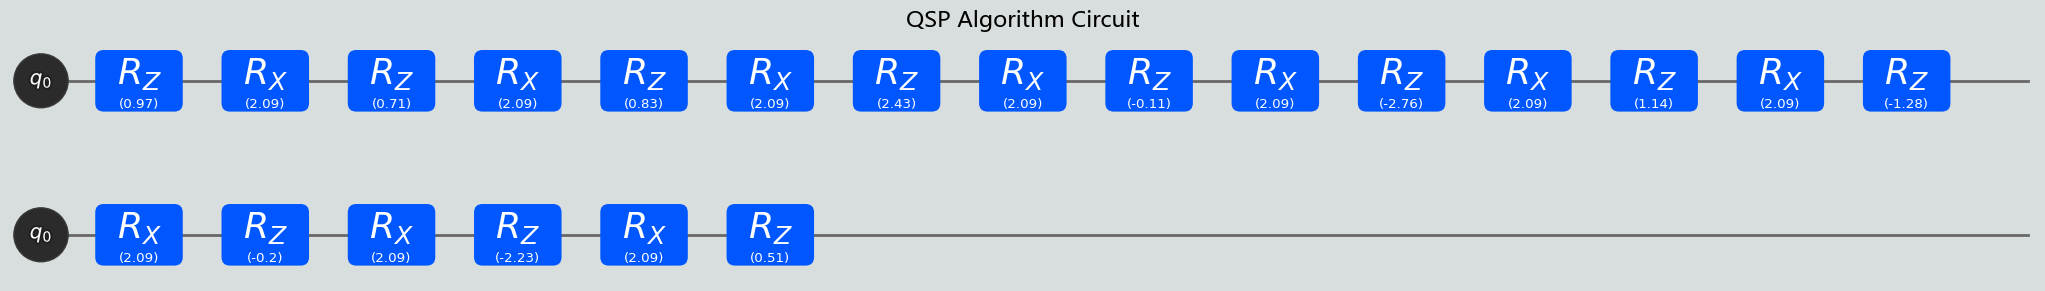

In [1]:
# 先绘制线路图
import numpy as np
from unitarylab_algorithms import QSPAlgorithm

%matplotlib inline

t = 1.0
degree = 10
x_test = 0.5

seed = 7
np.random.seed(seed)

qsp_algorithm = QSPAlgorithm(text_mode="plain")
qsp_result = qsp_algorithm.run(
    t=t, d=degree, x=x_test, backend="numpy", device="cpu", dtype=np.complex128
)

In [2]:
# 手写 QSP
from scipy.optimize import minimize


def signal_operator(x):
    """定义 signal operator"""
    s = np.sqrt(max(0.0, 1.0 - x**2))

    return np.array([[x, 1j * s], [1j * s, x]], dtype=complex)


def phase_gate(phi):
    """定义 phase gate"""

    return np.array([[np.exp(1j * phi), 0], [0, np.exp(-1j * phi)]], dtype=complex)


def qsp_matrix(x, phase):
    """定义 QSP matrix"""
    U = phase_gate(phase[0])
    W = signal_operator(x)

    for phi in phase[1:]:
        U = U @ W @ phase_gate(phi)

    return U


def qsp_value(x, phase):
    """计算 QSP value, 即 U[0, 0]"""

    return qsp_matrix(x, phase)[0, 0]

In [3]:
# 验证 phase=0 是否为 Chebychev
test_degree = 4
zero_phases = np.zeros(test_degree + 1)

x = 0.3

qsp_zero = qsp_value(x, zero_phases)
chebyshev_value = np.cos(test_degree * np.arccos(x))

print("QSP zero-phase =", qsp_zero)
print("T_d(x) =", chebyshev_value)

QSP zero-phase = (0.3448000000000001+0j)
T_d(x) = 0.34480000000000033


In [4]:
# 手写 phase optimization
sample_points = np.linspace(-1.0, 1.0, 2 * degree + 1)


def qsp_loss(phases):
    """定义损失函数"""
    errors = []

    for x in sample_points:
        estimate = qsp_value(x, phases)

        target = np.cos(t * x)
        errors.append(abs(estimate - target) ** 2)

    return float(np.mean(errors))


np.random.seed(seed)
initial_phases = np.random.randn(degree + 1) * 0.1

optimization = minimize(qsp_loss, initial_phases, method="L-BFGS-B")
manual_phases = optimization.x

print("Optimized QSP phases:")

for k, phi in enumerate(manual_phases):
    print(f"phi[{k}] = {phi:+.8f}")


Optimized QSP phases:
phi[0] = +0.48577845
phi[1] = +0.35626395
phi[2] = +0.41351983
phi[3] = +1.21532206
phi[4] = -0.05659674
phi[5] = -1.38144209
phi[6] = +0.56947428
phi[7] = -0.64153485
phi[8] = -0.09836413
phi[9] = -1.11447400
phi[10] = +0.25417588


In [5]:
# QSP 结果
manual_qsp_value = qsp_value(x_test, manual_phases)
ideal_value = np.cos(t * x_test)

manual_error = abs(manual_qsp_value - ideal_value)

print("Manual QSP value =", manual_qsp_value)
print("Ideal value =", ideal_value)
print("Manual error =", manual_error)

Manual QSP value = (0.8788294852399929-0.0075944536266449505j)
Ideal value = 0.8775825618903728
Manual error = 0.007696138234666049


In [6]:
# 官方数值结果
official_qsp_value = qsp_result["Estimated value"]
official_ideal = qsp_result["Ideal value"]
official_error = qsp_result["Absolute error"]

print("Official QSP value =", official_qsp_value)
print("Official ideal =", official_ideal)
print("Official error =", official_error)

Official QSP value = (0.8788294852399935+0.007594453626644921j)
Official ideal = 0.8775825618903728
Official error = 0.0076961382346661085


In [7]:
# 进行对比
print("\n========== QSP Comparison ==========")
print("Ideal =", ideal_value)
print("Manual =", manual_qsp_value)
print("Official =", official_qsp_value)
print("Manual error =", manual_error)
print("Official error =", official_error)


========== QSP Comparison ==========
Ideal = 0.8775825618903728
Manual = (0.8788294852399929-0.0075944536266449505j)
Official = (0.8788294852399935+0.007594453626644921j)
Manual error = 0.007696138234666049
Official error = 0.0076961382346661085


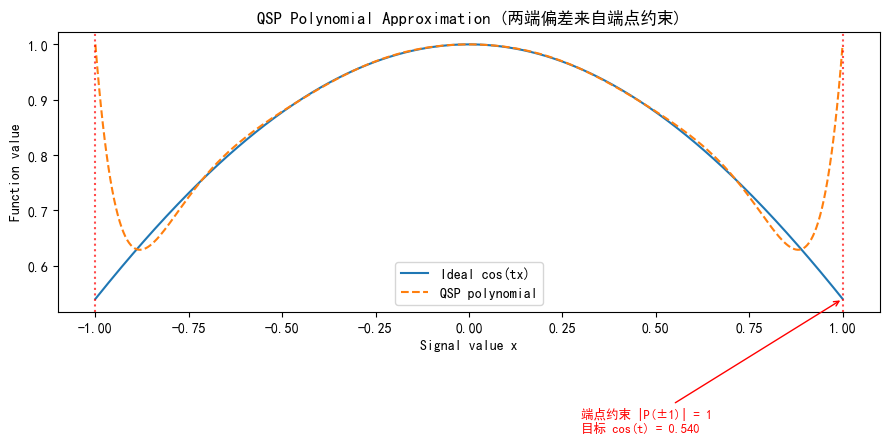

In [8]:
# 绘制 QSP 多项式
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 设置字体为黑体
plt.rcParams["font.family"] = [
    "sans-serif"
]  # 不要覆盖成 DejaVu Sans(不含中文, 会让中文显示为方框)
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题


x_grid = np.linspace(-1.0, 1.0, 401)
qsp_values = np.array([qsp_value(x, manual_phases) for x in x_grid])

ideal_values = np.cos(t * x_grid)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_grid, ideal_values, label="Ideal cos(tx)")
ax.plot(x_grid, np.real(qsp_values), linestyle="--", label="QSP polynomial")

# 标注端点约束: QSP 要求 |P(±1)| = 1, 而 cos(±t) ≠ ±1
ax.axvline(1.0, color="red", ls=":", alpha=0.7)
ax.axvline(-1.0, color="red", ls=":", alpha=0.7)
ax.annotate(
    "端点约束 |P(±1)| = 1\n目标 cos(t) = %.3f" % np.cos(t),
    xy=(1.0, np.cos(t)),
    xytext=(0.30, 0.30),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=9,
)

ax.set_xlabel("Signal value x")
ax.set_ylabel("Function value")
ax.set_title("QSP Polynomial Approximation (两端偏差来自端点约束)")
ax.legend()
fig.tight_layout()

plt.show()

### 为什么两端不重合: QSP 的端点约束

图片两端 $x \to \pm 1$ 处 QSP 多项式与理想 $\cos(tx)$ 明显分离, 这不是优化失败, 而是 QSP 表示定理的**硬约束**:

$$
|P(x)|^2 + (1-x^2)|Q(x)|^2 = 1 \quad\Longrightarrow\quad |P(\pm 1)| = 1
$$

即 QSP 能实现的任何多项式在端点 $x=\pm1$ 处模长必须为 1(与次数 $d$ 无关). 而目标函数 $\cos(tx)$ 在端点取值 $\cos(\pm t)=0.54\neq\pm1$, 故端点处最小可能误差为

$$
\min |P(\pm1)-\cos(\pm t)| = |1-\cos t| = 0.46,
$$

优化器已经达到这一数学下界(稠密网格上最大误差恰为 0.4597). 官方库报告的 error $0.0077$ 只在 $x=0.5$ 单点测量, 掩盖了端点问题. 若需消除端点偏差, 应选择满足 $|f(\pm1)|=1$ 的目标函数(如 $\cos(\pi x)$)或对目标做归一化处理.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

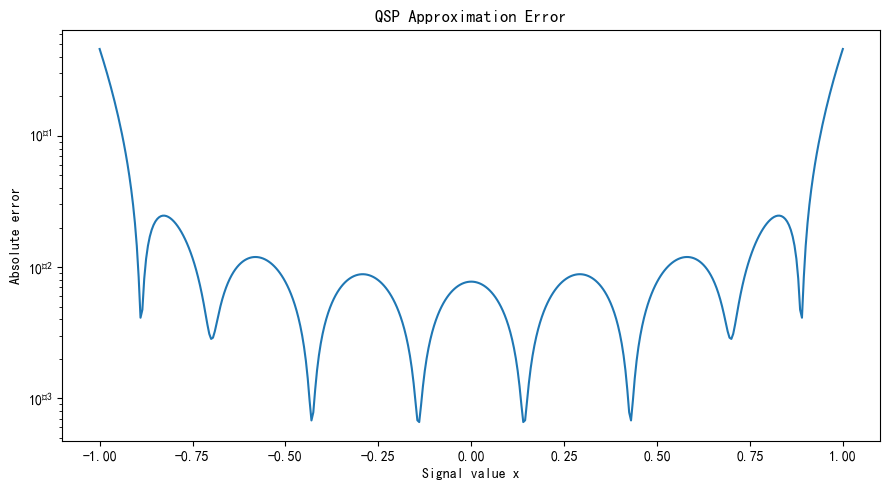

In [9]:
pointwise_error = np.abs(qsp_values - ideal_values)

fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(x_grid, np.maximum(pointwise_error, 1e-16))

ax.set_xlabel("Signal value x")
ax.set_ylabel("Absolute error")
ax.set_title("QSP Approximation Error")

fig.tight_layout()

plt.show()

### 1. 从标量多项式到矩阵多项式
到这里还是
$$
x\mapsto P(x)
$$
但我们真正的目标是
$$
H\mapsto P(H)
$$
若有:
$$
H=V\begin{bmatrix}
\lambda_1 & & \\
 & \lambda_2 & \\
  & & \ddots 
\end{bmatrix}V^\dagger
$$
则有:
$$
P(H)=V\begin{bmatrix}
P(\lambda_1) & & \\
& P(\lambda_2) & \\
  & & \ddots 
\end{bmatrix}V^\dagger
$$
QSP Hamiltonian simulation 正是 Low-Chuang QSP 的应用之一.

### 2. Hamiltonian simulation 的目标函数
我们想实现
$$
e^{-iHt}
$$
在标量层面是
$$
f(x)=e^{-itx}=\cos(tx)-i\sin(tx)
$$
所以问题自然拆成 $\cos(tx)$ 和 $\sin(tx)$ 两部分. 

### 3. 为什么 Chebyshev 再次出现
前面知道
$$
T_n(x)=\cos(n\arccos x)
$$
而且对于 $\cos(\tau x)$ 和 $\sin(\tau x)$, 存在 Chebyshev/Bessel 展开(也叫 Jacobi-Angle 展开)
$$
\cos(\tau x)=J_0(\tau)+2\sum_{k=1}^{\infty}(-1)^k J_{2k}(\tau) T_{2k}(x)
$$
和
$$
\sin(\tau x)=2\sum_{k=0}^{\infty}(-1)^k J_{2k+1}(\tau) T_{2k+1}(x)
$$
其中 $T_k$ 是 Chebyshev 多项式, $J_k$ 是 Bessel 多项式.

### 4. 本节 Hamiltonian 实验
继续使用矩阵
$$
H=\begin{bmatrix}
0.6 & 0.2 \\
0.2 & 0.2
\end{bmatrix}
$$
取 $t=1$, 目标是
$$
U_{exact}=e^{-iH}
$$

In [10]:
from unitarylab.library import block_encode

H = np.array([[0.6, 0.2], [0.2, 0.2]], dtype=complex)
be_result = block_encode(H, method="nagy")

alpha = be_result.alpha
B = H / alpha

由于 $H=\alpha B$, 所以有:
$$
e^{-iHt}=e^{-i(\alpha t)B}
$$
定义 $\tau=\alpha t$, 所以多项式实际逼近
$$
e^{-i\tau x},\quad x\in[-1,1]
$$

In [11]:
from scipy.linalg import expm
from scipy.special import jv

t_hs = 1.0
tau = alpha * t_hs


# 手写
def chebyshev_matrices(matrix, degree):
    dim = matrix.shape[0]

    T = [np.eye(dim, dtype=complex)]

    if degree == 0:
        return T

    T.append(matrix.copy())

    for k in range(1, degree):
        T_next = 2 * matrix @ T[k] - T[k - 1]

        T.append(T_next)

    return T


degree_hs = 15

cos_coefficients = np.zeros(degree_hs + 1)
sin_coefficients = np.zeros(degree_hs + 1)

# cos
cos_coefficients[0] = jv(0, tau)

for k in range(1, degree_hs + 1):
    if k % 2 == 0:
        cos_coefficients[k] = 2 * ((-1) ** (k // 2)) * jv(k, tau)

# sin
for k in range(degree_hs + 1):
    if k % 2 == 1:
        sin_coefficients[k] = 2 * ((-1) ** ((k - 1) // 2)) * jv(k, tau)

# 构造矩阵多项式
T_matrices = chebyshev_matrices(B, degree_hs)

# cos
cos_poly = np.zeros_like(B, dtype=complex)

for k in range(degree_hs + 1):
    cos_poly += cos_coefficients[k] * T_matrices[k]

# sin
sin_poly = np.zeros_like(B, dtype=complex)

for k in range(degree_hs + 1):
    sin_poly += sin_coefficients[k] * T_matrices[k]

# 手写 QSP Hamiltonian Simulation
U_manual_qsp = cos_poly - 1j * sin_poly

# 精确的 Hamiltonian evolution
U_exact = expm(-1j * H * t_hs)

In [12]:
# 误差
manual_hs_error = np.linalg.norm(U_manual_qsp - U_exact, ord="fro")

print("Manual QSP-HS error =", manual_hs_error)

Manual QSP-HS error = 2.0301453349424727e-16


[QSP_HS]: Starting QSP Hamiltonian Simulation Algorithm
[QSP_HS]: Input parameters: 
        - Hamiltonian = [[0.6+0.j 0.2+0.j]
 [0.2+0.j 0.2+0.j]]
        - Evolution time = 1.0
        - error = 0.0001
        - degree = 15
        - beta = 0.7
[QSP_HS]: Stage 1: Formatting and validating input.
[QSP_HS]:     Block-encoded Hamiltonian with α=1.0000 using 1 qubits.
[QSP_HS]: Stage 2: Estimating required QSP degree and time slicing.
[QSP_HS]:     Chosen time slices: 1, slice time: 1.0000, target degree per slice: 11.
[QSP_HS]: Stage 3: Constructing QSP circuit for one time slice and composing by matrix power.
[QSP_HS]:     Approximating the real component (cos) for t = 1.0000
[QSP_HS]:     Approximating the imaginary component (sin) for t = 1.0000
[QSP_HS]:     Combining cos and sin components via LCU to construct the final QSP circuit for one slice.
[QSP_HS]: Stage 4: Computing exact and approximate evolution matrices for error estimation.
[QSP_HS]: Output information: 
        - Appr

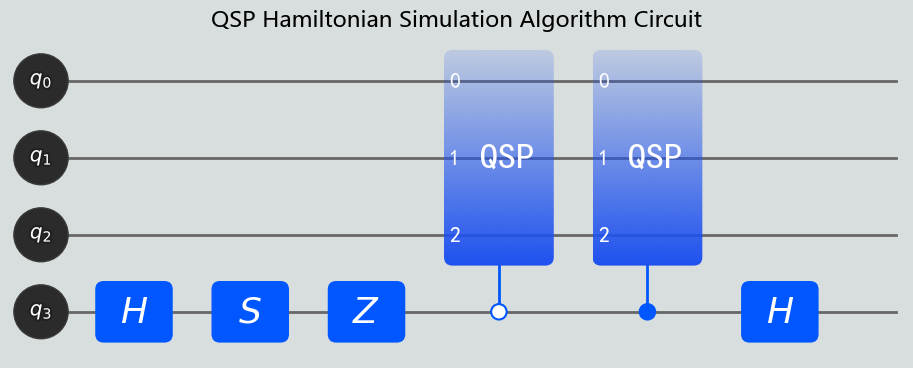

In [13]:
# 官方实现
from unitarylab_algorithms import QSPHSAlgorithm

qsp_hs_algorithm = QSPHSAlgorithm(text_mode="plain")
qsp_hs_result = qsp_hs_algorithm.run(
    H=H,
    t=t_hs,
    error=1e-4,
    degree=degree_hs,
    beta=0.7,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [14]:
official_qsp_hs_U = np.asarray(qsp_hs_result["Approximate evolution matrix"])
official_exact_U = np.asarray(qsp_hs_result["Exact evolution matrix"])
official_hs_error = qsp_hs_result["Frobenius norm of error"]

print("\n========== QSP Hamiltonian Simulation ==========")
print("Manual error =", manual_hs_error)
print("Official error =", official_hs_error)
print(
    "Manual vs Official =", np.linalg.norm(U_manual_qsp - official_qsp_hs_U, ord="fro")
)


========== QSP Hamiltonian Simulation ==========
Manual error = 2.0301453349424727e-16
Official error = 1.2005791794521563e-12
Manual vs Official = 1.2006662699086204e-12


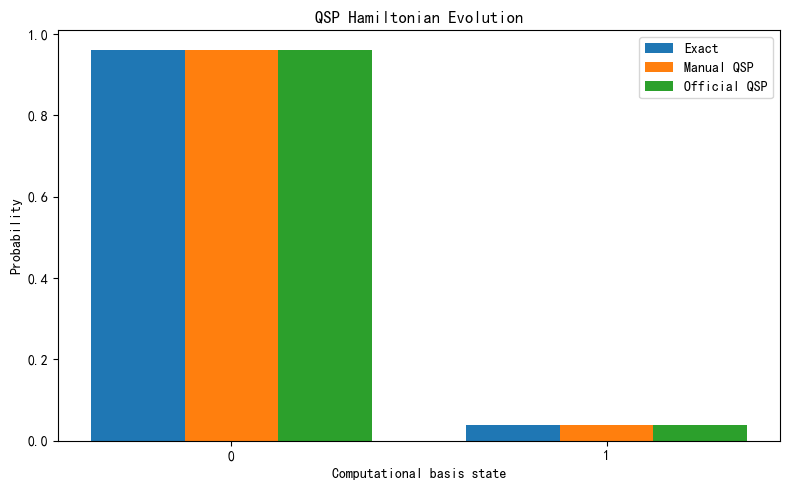

In [15]:
# 比较作用在量子态上的结果 |0>
psi_0 = np.array([1, 0], dtype=complex)
psi_exact = U_exact @ psi_0
psi_manual = U_manual_qsp @ psi_0
psi_official = official_qsp_hs_U @ psi_0

# 概率分布
prob_exact = np.abs(psi_exact) ** 2
prob_manual = np.abs(psi_manual) ** 2
prob_official = np.abs(psi_official) ** 2

# 绘制
basis_states = ["0", "1"]

x = np.arange(len(basis_states))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, prob_exact, width, label="Exact")
ax.bar(x, prob_manual, width, label="Manual QSP")
ax.bar(x + width, prob_official, width, label="Official QSP")

ax.set_xticks(x)
ax.set_xticklabels(basis_states)
ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_title("QSP Hamiltonian Evolution")
ax.legend()

fig.tight_layout()
plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

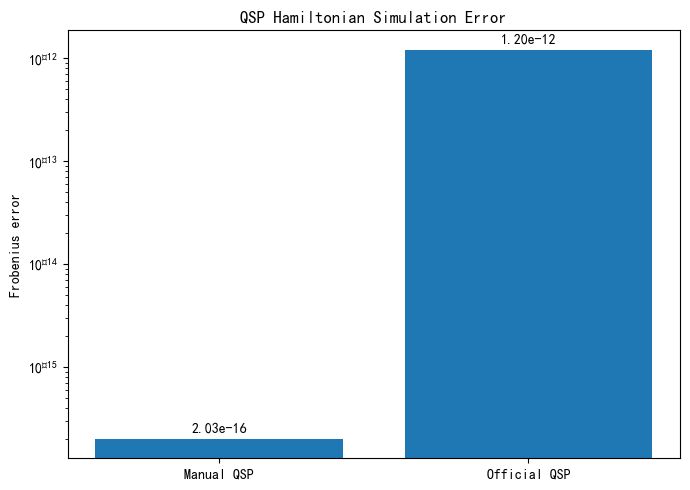

In [16]:
# 绘制哈密顿量模拟误差
methods = ["Manual QSP", "Official QSP"]
errors = [manual_hs_error, official_hs_error]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(methods, errors)

ax.bar_label(bars, labels=[f"{error:.2e}" for error in errors], padding=3)
ax.set_yscale("log")
ax.set_ylabel("Frobenius error")
ax.set_title("QSP Hamiltonian Simulation Error")

fig.tight_layout()
plt.show()